# 🎮 Video Game Sales & Engagement Analysis
## 🧹 Data Cleaning Notebook
---
**Datasets Used:**
- [`games.csv`](https://drive.google.com/file/d/1xTtPz0zTVpcoYe0c4Cq6xy8K-1qJj0K8/view?usp=sharing) — Game engagement data (ratings, plays, wishlists, backlogs)
- [`vgsales.csv`](https://drive.google.com/file/d/12b6CrDddupzYpcDkkJUlNRG04ehnEENU/view?usp=sharing) — Video game sales data (platform, region-wise sales)

**Cleaning Steps Covered:**
1. Import Libraries & Load Data
2. Initial Exploration
3. Handle Duplicates
4. Handle Missing Values
5. Fix Data Types & Parse Special Formats
6. Normalize Categorical Fields
7. Feature Engineering
8. Merge Datasets
9. Export Cleaned Data
10. Final Summary Report


## Step 1 — Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import re
import os
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#6C63FF','#FF6584','#43B89C','#FFC75F','#A78BFA','#34D399']
sns.set_palette(PALETTE)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [2]:
# Load raw datasets
games_raw  = pd.read_csv('games.csv')
vgsales_raw = pd.read_csv('vgsales.csv')

print(f'games.csv   shape : {games_raw.shape}')
print(f'vgsales.csv shape : {vgsales_raw.shape}')

games.csv   shape : (1512, 14)
vgsales.csv shape : (16598, 11)


## Step 2 — Initial Data Exploration

In [3]:
print('=' * 55)
print('  games.csv — First 5 Rows')
print('=' * 55)
display(games_raw.head())

  games.csv — First 5 Rows


,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


In [4]:
print('=' * 55)
print('  vgsales.csv — First 5 Rows')
print('=' * 55)
display(vgsales_raw.head())

  vgsales.csv — First 5 Rows


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [5]:
# Shape & Data Types
print('── games.csv Info ──')
games_raw.info()
print()
print('── vgsales.csv Info ──')
vgsales_raw.info()

── games.csv Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB

── vgsales.csv Info ──
<class 'pandas.

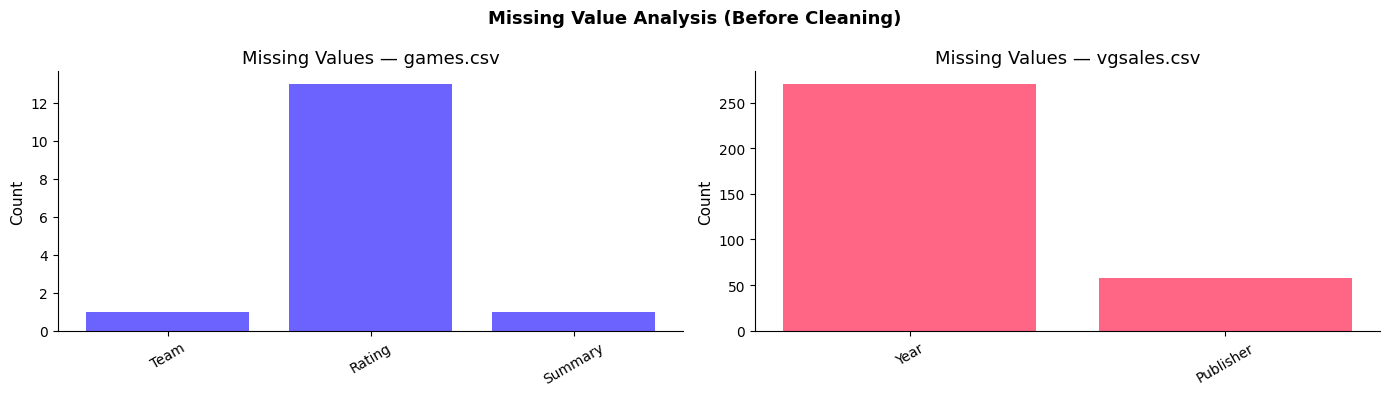

games.csv missing values:
Unnamed: 0            0
Title                 0
Release Date          0
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

vgsales.csv missing values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [6]:
# Missing values heatmap — games.csv
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# games missing
g_null = games_raw.isnull().sum().reset_index()
g_null.columns = ['Column', 'Missing']
g_null = g_null[g_null['Missing'] > 0]
if len(g_null):
    axes[0].bar(g_null['Column'], g_null['Missing'], color=PALETTE[0])
    axes[0].set_title('Missing Values — games.csv')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)
else:
    axes[0].text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=13)
    axes[0].set_title('Missing Values — games.csv')

# vgsales missing
v_null = vgsales_raw.isnull().sum().reset_index()
v_null.columns = ['Column', 'Missing']
v_null = v_null[v_null['Missing'] > 0]
if len(v_null):
    axes[1].bar(v_null['Column'], v_null['Missing'], color=PALETTE[1])
    axes[1].set_title('Missing Values — vgsales.csv')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=30)
else:
    axes[1].text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=13)
    axes[1].set_title('Missing Values — vgsales.csv')

plt.suptitle('Missing Value Analysis (Before Cleaning)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('games.csv missing values:')
print(games_raw.isnull().sum())
print()
print('vgsales.csv missing values:')
print(vgsales_raw.isnull().sum())

In [7]:
# Basic statistics
print('── games.csv Numeric Stats ──')
display(games_raw[['Rating']].describe())

print('── vgsales.csv Numeric Stats ──')
display(vgsales_raw[['Year','NA_Sales','EU_Sales','JP_Sales','Global_Sales']].describe())

── games.csv Numeric Stats ──


,Rating
count,1499.000000
mean,3.719346
std,0.532608
min,0.700000
25%,3.400000
50%,3.800000
75%,4.100000
max,4.800000


── vgsales.csv Numeric Stats ──


,Year,NA_Sales,EU_Sales,JP_Sales,Global_Sales
count,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,2006.406443,0.264667,0.146652,0.077782,0.537441
std,5.828981,0.816683,0.505351,0.309291,1.555028
min,1980.000000,0.000000,0.000000,0.000000,0.010000
25%,2003.000000,0.000000,0.000000,0.000000,0.060000
50%,2007.000000,0.080000,0.020000,0.000000,0.170000
75%,2010.000000,0.240000,0.110000,0.040000,0.470000
max,2020.000000,41.490000,29.020000,10.220000,82.740000


## Step 3 — Handle Duplicates

In [8]:
# Work on copies
games   = games_raw.copy()
vgsales = vgsales_raw.copy()

# Check duplicates in games.csv
dup_games = games.duplicated(subset=['Title']).sum()
print(f'Duplicate game titles in games.csv   : {dup_games}')

# Check duplicates in vgsales.csv
dup_sales = vgsales.duplicated(subset=['Name', 'Platform']).sum()
print(f'Duplicate (Name+Platform) in vgsales : {dup_sales}')

# Show some duplicate examples from games.csv
if dup_games > 0:
    print('\nSample duplicate titles:')
    dup_titles = games[games.duplicated(subset=['Title'], keep=False)].sort_values('Title')
    display(dup_titles[['Title','Rating','Genres']].head(6))

Duplicate game titles in games.csv   : 413
Duplicate (Name+Platform) in vgsales : 5

Sample duplicate titles:


,Title,Rating,Genres
969,A Plague Tale: Innocence,3.7,"['Adventure', 'RPG']"
187,A Plague Tale: Innocence,3.7,"['Adventure', 'RPG']"
454,A Plague Tale: Innocence,3.7,"['Adventure', 'RPG']"
463,AI: The Somnium Files - Nirvana Initiative,3.9,"['Adventure', 'Puzzle', 'Visual Novel']"
196,AI: The Somnium Files - Nirvana Initiative,3.9,"['Adventure', 'Puzzle', 'Visual Novel']"
769,Agar.io,2.2,"['Indie', 'Strategy']"


In [9]:
# Remove duplicates
before_games   = len(games)
before_sales   = len(vgsales)

games.drop_duplicates(subset=['Title'], keep='first', inplace=True)
vgsales.drop_duplicates(subset=['Name', 'Platform'], keep='first', inplace=True)

# Drop unnamed index column in games
games.drop(columns=[c for c in games.columns if 'Unnamed' in c], inplace=True)

print(f'games.csv   : {before_games} → {len(games)} rows  ({before_games - len(games)} duplicates removed)')
print(f'vgsales.csv : {before_sales} → {len(vgsales)} rows  ({before_sales - len(vgsales)} duplicates removed)')

games.csv   : 1512 → 1099 rows  (413 duplicates removed)
vgsales.csv : 16598 → 16593 rows  (5 duplicates removed)


## Step 4 — Handle Missing Values

### 4.1 — games.csv: Fill Missing Rating

Rating column - before:
  Missing : 13
  Mean    : 3.65
  Median  : 3.70


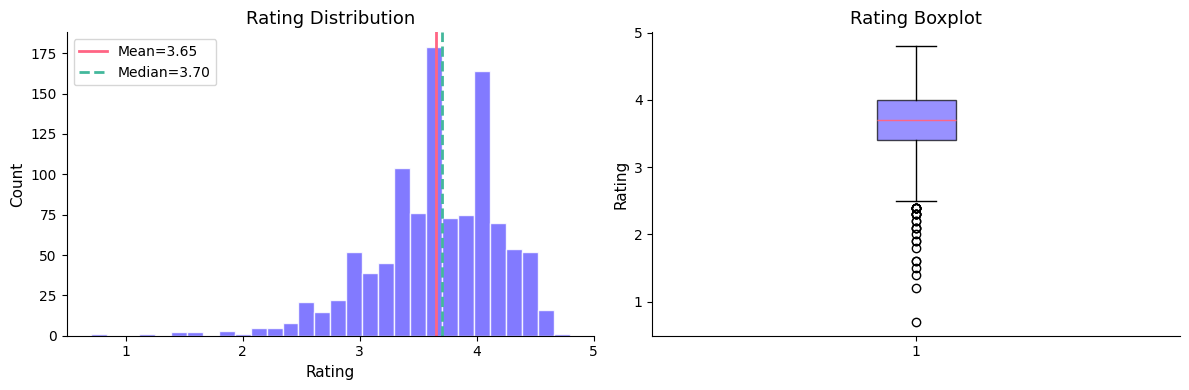


✅ Filled 0 missing ratings with median = 3.7


In [10]:
print('Rating column - before:')
print(f'  Missing : {games["Rating"].isna().sum()}')
print(f'  Mean    : {games["Rating"].mean():.2f}')
print(f'  Median  : {games["Rating"].median():.2f}')

# Visualise rating distribution to decide fill strategy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(games['Rating'].dropna(), bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(games['Rating'].mean(),   color=PALETTE[1], lw=2, label=f'Mean={games["Rating"].mean():.2f}')
axes[0].axvline(games['Rating'].median(), color=PALETTE[2], lw=2, ls='--', label=f'Median={games["Rating"].median():.2f}')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(games['Rating'].dropna(), patch_artist=True,
    boxprops=dict(facecolor=PALETTE[0], alpha=0.7))
axes[1].set_title('Rating Boxplot')
axes[1].set_ylabel('Rating')

plt.tight_layout(); plt.show()

# Fill with median (rating is slightly skewed)
median_rating = games['Rating'].median()
games['Rating'] = games['Rating'].fillna(median_rating)
print(f'\n✅ Filled {games["Rating"].isna().sum()} missing ratings with median = {median_rating}')

### 4.2 — games.csv: Handle Missing Team/Summary

In [11]:
print('Missing before fill:')
print(games[['Team','Summary']].isnull().sum())

# Fill Team with 'Unknown'
games['Team'] = games['Team'].fillna("['Unknown']")

# Drop Summary — not needed for analysis
games.drop(columns=['Summary', 'Reviews'], inplace=True, errors='ignore')

print('\n✅ Team missing filled with Unknown')
print('✅ Summary and Reviews columns dropped (not needed for analysis)')

Missing before fill:
Team       1
Summary    1
dtype: int64

✅ Team missing filled with Unknown
✅ Summary and Reviews columns dropped (not needed for analysis)


### 4.3 — vgsales.csv: Handle Missing Year & Publisher

In [12]:
print('Before — vgsales missing:')
print(vgsales[['Year', 'Publisher']].isnull().sum())

# Drop rows with clearly invalid years
vgsales['Year'] = pd.to_numeric(vgsales['Year'], errors='coerce')
invalid_mask = (vgsales['Year'] > 2023) | (vgsales['Year'] < 1980)
print(f'\nInvalid year rows (outside 1980–2023): {invalid_mask.sum()}')
vgsales = vgsales[~invalid_mask | vgsales['Year'].isna()]

# Fill missing Year with platform mode
vgsales['Year'] = vgsales.groupby('Platform')['Year'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
vgsales['Year'] = vgsales['Year'].astype('Int64')

# Fill missing Publisher with 'Unknown'
vgsales['Publisher'] = vgsales['Publisher'].fillna('Unknown')

print('\nAfter — vgsales missing:')
print(vgsales[['Year', 'Publisher']].isnull().sum())
print('\n✅ Year filled via platform mode | Publisher filled with Unknown')

Before — vgsales missing:
Year         269
Publisher     57
dtype: int64

Invalid year rows (outside 1980–2023): 0

After — vgsales missing:
Year         0
Publisher    0
dtype: int64

✅ Year filled via platform mode | Publisher filled with Unknown


## Step 5 — Fix Data Types & Parse Special Formats

### 5.1 — Parse K/M Notation (Plays, Wishlist, Backlogs, etc.)

In [13]:
# These columns have values like '3.9K', '1.2M', '230'
print('Sample raw values:')
print(games[['Plays','Backlogs','Wishlist','Times Listed','Number of Reviews']].head(5))


Sample raw values:
  Plays Backlogs Wishlist Times Listed Number of Reviews
0   17K     4.6K     4.8K         3.9K              3.9K
1   21K     6.3K     3.6K         2.9K              2.9K
2   30K       5K     2.6K         4.3K              4.3K
3   28K     4.9K     1.8K         3.5K              3.5K
4   21K     8.3K     2.3K           3K                3K


In [14]:
def parse_k_notation(val):
    """Convert '3.9K' → 3900.0, '1.2M' → 1200000.0"""
    if pd.isna(val):
        return np.nan
    val = str(val).strip().replace(',', '')
    if val.upper().endswith('K'):
        return float(val[:-1]) * 1_000
    if val.upper().endswith('M'):
        return float(val[:-1]) * 1_000_000
    try:
        return float(val)
    except ValueError:
        return np.nan

# Apply to all engagement columns
engagement_cols = ['Plays', 'Playing', 'Backlogs', 'Wishlist', 'Times Listed', 'Number of Reviews']
for col in engagement_cols:
    games[col] = games[col].apply(parse_k_notation)

print('After conversion:')
display(games[engagement_cols].head(5))
print()
print('Data types:')
print(games[engagement_cols].dtypes)

After conversion:


,Plays,Playing,Backlogs,Wishlist,Times Listed,Number of Reviews
0,17000.0,3800.0,4600.0,4800.0,3900.0,3900.0
1,21000.0,3200.0,6300.0,3600.0,2900.0,2900.0
2,30000.0,2500.0,5000.0,2600.0,4300.0,4300.0
3,28000.0,679.0,4900.0,1800.0,3500.0,3500.0
4,21000.0,2400.0,8300.0,2300.0,3000.0,3000.0



Data types:
Plays                float64
Playing              float64
Backlogs             float64
Wishlist             float64
Times Listed         float64
Number of Reviews    float64
dtype: object


### 5.2 — Parse Release Date → Year & Month

In [15]:
print('Sample Release Date values:')
print(games['Release Date'].head(8).tolist())
print()
print('Date formats found:')
print(games['Release Date'].value_counts().head(5))


Sample Release Date values:
['Feb 25, 2022', 'Dec 10, 2019', 'Mar 03, 2017', 'Sep 15, 2015', 'Feb 24, 2017', 'Nov 18, 2011', 'Dec 25, 2020', 'Oct 07, 2021']

Date formats found:
Release Date
Nov 12, 2020    5
Sep 26, 2013    3
Dec 02, 2022    3
Dec 20, 2001    3
Dec 22, 2005    3
Name: count, dtype: int64


In [16]:
# Convert to datetime
games['Release Date'] = pd.to_datetime(games['Release Date'], errors='coerce')

# Extract year and month
games['Release_Year']  = games['Release Date'].dt.year.astype('Int64')
games['Release_Month'] = games['Release Date'].dt.month.astype('Int64')

print(f'Parsed dates successfully | Unparseable: {games["Release_Year"].isna().sum()}')
display(games[['Title','Release Date','Release_Year','Release_Month']].head(5))

Parsed dates successfully | Unparseable: 3


,Title,Release Date,Release_Year,Release_Month
0,Elden Ring,2022-02-25,2022,2
1,Hades,2019-12-10,2019,12
2,The Legend of Zelda: Breath of the Wild,2017-03-03,2017,3
3,Undertale,2015-09-15,2015,9
4,Hollow Knight,2017-02-24,2017,2


### 5.3 — Parse List-Format Fields (Genres, Team)

In [17]:
print('Sample raw Genres values:')
print(games['Genres'].head(5).tolist())
print()
print('Sample raw Team values:')
print(games['Team'].head(5).tolist())


Sample raw Genres values:
["['Adventure', 'RPG']", "['Adventure', 'Brawler', 'Indie', 'RPG']", "['Adventure', 'RPG']", "['Adventure', 'Indie', 'RPG', 'Turn Based Strategy']", "['Adventure', 'Indie', 'Platform']"]

Sample raw Team values:
["['Bandai Namco Entertainment', 'FromSoftware']", "['Supergiant Games']", "['Nintendo', 'Nintendo EPD Production Group No. 3']", "['tobyfox', '8-4']", "['Team Cherry']"]


In [ ]:
def parse_list_field(val):
    """Convert \"['Adventure', 'RPG']\" string → Python list""" 
    if pd.isna(val):
        return []
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else [result]
    except Exception:
        cleaned = re.sub(r"[\[\]]", '', str(val))
        return [v.strip().strip("'\"")
                for v in cleaned.split(',') if v.strip()]

# Parse genres and team into lists
games['Genres_List'] = games['Genres'].apply(parse_list_field)
games['Team_List']   = games['Team'].apply(parse_list_field)

# Extract primary (first) value
games['Primary_Genre']     = games['Genres_List'].apply(lambda x: x[0] if x else None)
games['Primary_Developer'] = games['Team_List'].apply(lambda x: x[0] if x else None)

# Create clean comma-separated string
games['Genres_Clean'] = games['Genres_List'].apply(lambda x: ', '.join(x))
games['Team_Clean']   = games['Team_List'].apply(lambda x: ', '.join(x))

# Drop original raw list columns
games.drop(columns=['Genres', 'Team', 'Genres_List', 'Team_List'], inplace=True)

print('✅ Genres and Team parsed successfully')
display(games[['Title','Primary_Genre','Genres_Clean','Primary_Developer','Team_Clean']].head(5))

✅ Genres and Team parsed successfully


,Title,Primary_Genre,Genres_Clean,Primary_Developer,Team_Clean
0,Elden Ring,Adventure,"Adventure, RPG",Bandai Namco Entertainment,"Bandai Namco Entertainment, FromSoftware"
1,Hades,Adventure,"Adventure, Brawler, Indie, RPG",Supergiant Games,Supergiant Games
2,The Legend of Zelda: Breath of the Wild,Adventure,"Adventure, RPG",Nintendo,"Nintendo, Nintendo EPD Production Group No. 3"
3,Undertale,Adventure,"Adventure, Indie, RPG, Turn Based Strategy",tobyfox,"tobyfox, 8-4"
4,Hollow Knight,Adventure,"Adventure, Indie, Platform",Team Cherry,Team Cherry


## Step 6 — Normalize Categorical Fields

### 6.1 — Normalize Platform Names (vgsales)

In [19]:
print('Unique platforms before normalization:')
print(sorted(vgsales['Platform'].unique()))


Unique platforms before normalization:
['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG', 'N64', 'NES', 'NG', 'PC', 'PCFX', 'PS', 'PS2', 'PS3', 'PS4', 'PSP', 'PSV', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'Wii', 'WiiU', 'X360', 'XB', 'XOne']


In [20]:
platform_map = {
    'X360':'Xbox 360', 'XB':'Xbox', 'XOne':'Xbox One',
    'PS':'PS1', 'PS2':'PS2', 'PS3':'PS3', 'PS4':'PS4',
    'PSP':'PSP', 'PSV':'PS Vita',
    'Wii':'Wii', 'WiiU':'Wii U',
    'DS':'Nintendo DS', '3DS':'Nintendo 3DS',
    'GBA':'Game Boy Advance', 'GC':'GameCube',
    'N64':'Nintendo 64', 'SNES':'SNES', 'NES':'NES',
    'GB':'Game Boy', 'DC':'Dreamcast',
    'SAT':'Sega Saturn', 'GEN':'Sega Genesis',
    '2600':'Atari 2600', 'NG':'Neo Geo',
    'SCD':'Sega CD', 'WS':'WonderSwan',
    'TG16':'TurboGrafx-16', '3DO':'3DO',
    'PCFX':'PC-FX', 'PC':'PC'
}

vgsales['Platform'] = vgsales['Platform'].map(platform_map).fillna(vgsales['Platform'])

print('Unique platforms after normalization:')
print(sorted(vgsales['Platform'].unique()))

Unique platforms after normalization:
['3DO', 'Atari 2600', 'Dreamcast', 'GG', 'Game Boy', 'Game Boy Advance', 'GameCube', 'NES', 'Neo Geo', 'Nintendo 3DS', 'Nintendo 64', 'Nintendo DS', 'PC', 'PC-FX', 'PS Vita', 'PS1', 'PS2', 'PS3', 'PS4', 'PSP', 'SNES', 'Sega CD', 'Sega Genesis', 'Sega Saturn', 'TurboGrafx-16', 'Wii', 'Wii U', 'WonderSwan', 'Xbox', 'Xbox 360', 'Xbox One']


### 6.2 — Normalize Genre Casing (vgsales)

In [21]:
print('Genres before:', vgsales['Genre'].unique())

vgsales['Genre'] = vgsales['Genre'].str.strip().str.title()

print('Genres after :', sorted(vgsales['Genre'].unique()))

Genres before: ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
Genres after : ['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle', 'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports', 'Strategy']


### 6.3 — Fill Remaining Missing Developer

In [22]:
games['Primary_Developer'] = games['Primary_Developer'].fillna('Unknown')
games['Team_Clean']        = games['Team_Clean'].fillna('Unknown')

print('Remaining nulls in games:')
print(games.isnull().sum()[games.isnull().sum() > 0])

Remaining nulls in games:
Release Date     3
Release_Year     3
Release_Month    3
Primary_Genre    3
dtype: int64


## Step 7 — Feature Engineering

In [23]:
# ── games.csv new features ────────────────────────────
# Engagement score (weighted combination)
games['Engagement_Score'] = (
    games['Plays'].fillna(0) * 1.0 +
    games['Wishlist'].fillna(0) * 2.0 +
    games['Backlogs'].fillna(0) * 1.5
) / 1000

# Demand index = wishlist / (plays + 1)
games['Demand_Index'] = games['Wishlist'].fillna(0) / (games['Plays'].fillna(0) + 1)

# Rating tier
games['Rating_Tier'] = pd.cut(
    games['Rating'],
    bins=[0, 3.0, 4.0, 5.0],
    labels=['Low (<3)', 'Medium (3-4)', 'High (4+)']
)

print('New features added to games.csv:')
display(games[['Title','Rating','Rating_Tier','Engagement_Score','Demand_Index']].head(8))

New features added to games.csv:


,Title,Rating,Rating_Tier,Engagement_Score,Demand_Index
0,Elden Ring,4.5,High (4+),33.50,0.282336
1,Hades,4.3,High (4+),37.65,0.171420
2,The Legend of Zelda: Breath of the Wild,4.4,High (4+),42.70,0.086664
3,Undertale,4.2,High (4+),38.95,0.064283
4,Hollow Knight,4.4,High (4+),38.05,0.109519
5,Minecraft,4.3,High (4+),35.11,0.006969
6,Omori,4.2,High (4+),21.55,0.527704
7,Metroid Dread,4.3,High (4+),20.90,0.358657


In [24]:
# ── vgsales.csv new features ──────────────────────────
# Sales tier
vgsales['Sales_Tier'] = pd.cut(
    vgsales['Global_Sales'],
    bins=[-1, 0.1, 1.0, 5.0, 1000],
    labels=['Low (<0.1M)', 'Mid (0.1-1M)', 'Hit (1-5M)', 'Blockbuster (5M+)']
)

# Decade column
vgsales['Decade'] = (vgsales['Year'] // 10 * 10).astype('Int64').astype(str) + 's'

# NA dominance flag
vgsales['NA_Dominant'] = vgsales['NA_Sales'] > vgsales[['EU_Sales','JP_Sales']].max(axis=1)

print('New features added to vgsales.csv:')
display(vgsales[['Name','Platform','Year','Decade','Global_Sales','Sales_Tier','NA_Dominant']].head(8))

New features added to vgsales.csv:


,Name,Platform,Year,Decade,Global_Sales,Sales_Tier,NA_Dominant
0,Wii Sports,Wii,2006,2000s,82.74,Blockbuster (5M+),True
1,Super Mario Bros.,NES,1985,1980s,40.24,Blockbuster (5M+),True
2,Mario Kart Wii,Wii,2008,2000s,35.82,Blockbuster (5M+),True
3,Wii Sports Resort,Wii,2009,2000s,33.00,Blockbuster (5M+),True
4,Pokemon Red/Pokemon Blue,Game Boy,1996,1990s,31.37,Blockbuster (5M+),True
5,Tetris,Game Boy,1989,1980s,30.26,Blockbuster (5M+),True
6,New Super Mario Bros.,Nintendo DS,2006,2000s,30.01,Blockbuster (5M+),True
7,Wii Play,Wii,2006,2000s,29.02,Blockbuster (5M+),True


## Step 8 — Rename Columns & Final Structure

In [25]:
# Rename for consistency
games.rename(columns={'Title': 'Game_Title'}, inplace=True)
vgsales.rename(columns={'Name': 'Game_Title'}, inplace=True)

# Add unique IDs
games.reset_index(drop=True, inplace=True)
vgsales.reset_index(drop=True, inplace=True)
games['game_id']  = games.index + 1
vgsales['sales_id'] = vgsales.index + 1

print('Final games.csv columns:')
print(list(games.columns))

print('\nFinal vgsales.csv columns:')
print(list(vgsales.columns))

Final games.csv columns:
['Game_Title', 'Release Date', 'Rating', 'Times Listed', 'Number of Reviews', 'Plays', 'Playing', 'Backlogs', 'Wishlist', 'Release_Year', 'Release_Month', 'Primary_Genre', 'Primary_Developer', 'Genres_Clean', 'Team_Clean', 'Engagement_Score', 'Demand_Index', 'Rating_Tier', 'game_id']

Final vgsales.csv columns:
['Rank', 'Game_Title', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Sales_Tier', 'Decade', 'NA_Dominant', 'sales_id']


## Step 9 — Merge Datasets

In [26]:
# Normalize title key for fuzzy join
games['_key']   = games['Game_Title'].str.strip().str.lower()
vgsales['_key'] = vgsales['Game_Title'].str.strip().str.lower()

# Aggregate vgsales per title (sum across platforms)
sales_agg = vgsales.groupby('_key').agg(
    NA_Sales    = ('NA_Sales',    'sum'),
    EU_Sales    = ('EU_Sales',    'sum'),
    JP_Sales    = ('JP_Sales',    'sum'),
    Other_Sales = ('Other_Sales', 'sum'),
    Global_Sales= ('Global_Sales','sum'),
    Publisher   = ('Publisher',   'first'),
    Genre_Sales = ('Genre',       'first'),
    Platforms   = ('Platform',    lambda x: ', '.join(sorted(x.unique())))
).reset_index()

# Merge on key
merged = games.merge(sales_agg, on='_key', how='left')
merged.drop(columns=['_key'], inplace=True)
vgsales.drop(columns=['_key'], inplace=True)
games.drop(columns=['_key'], inplace=True)

# Fill unmatched sales with 0
for col in ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']:
    merged[col] = merged[col].fillna(0)

matched = (merged['Global_Sales'] > 0).sum()
print(f'Matched games (found in both datasets) : {matched} / {len(merged)}')
print(f'Final merged shape                      : {merged.shape}')
display(merged[['Game_Title','Rating','Primary_Genre','Global_Sales','Publisher','Platforms']].head(8))

Matched games (found in both datasets) : 469 / 1099
Final merged shape                      : (1099, 27)


,Game_Title,Rating,Primary_Genre,Global_Sales,Publisher,Platforms
0,Elden Ring,4.5,Adventure,0.00,NaN,NaN
1,Hades,4.3,Adventure,0.00,NaN,NaN
2,The Legend of Zelda: Breath of the Wild,4.4,Adventure,0.00,NaN,NaN
3,Undertale,4.2,Adventure,0.00,NaN,NaN
4,Hollow Knight,4.4,Adventure,0.00,NaN,NaN
5,Minecraft,4.3,Adventure,23.73,Microsoft Game Studios,"PS Vita, PS3, PS4, Wii U, Xbox 360, Xbox One"
6,Omori,4.2,Adventure,0.00,NaN,NaN
7,Metroid Dread,4.3,Adventure,0.00,NaN,NaN


## Step 10 — Post-Cleaning Validation & Visual Summary

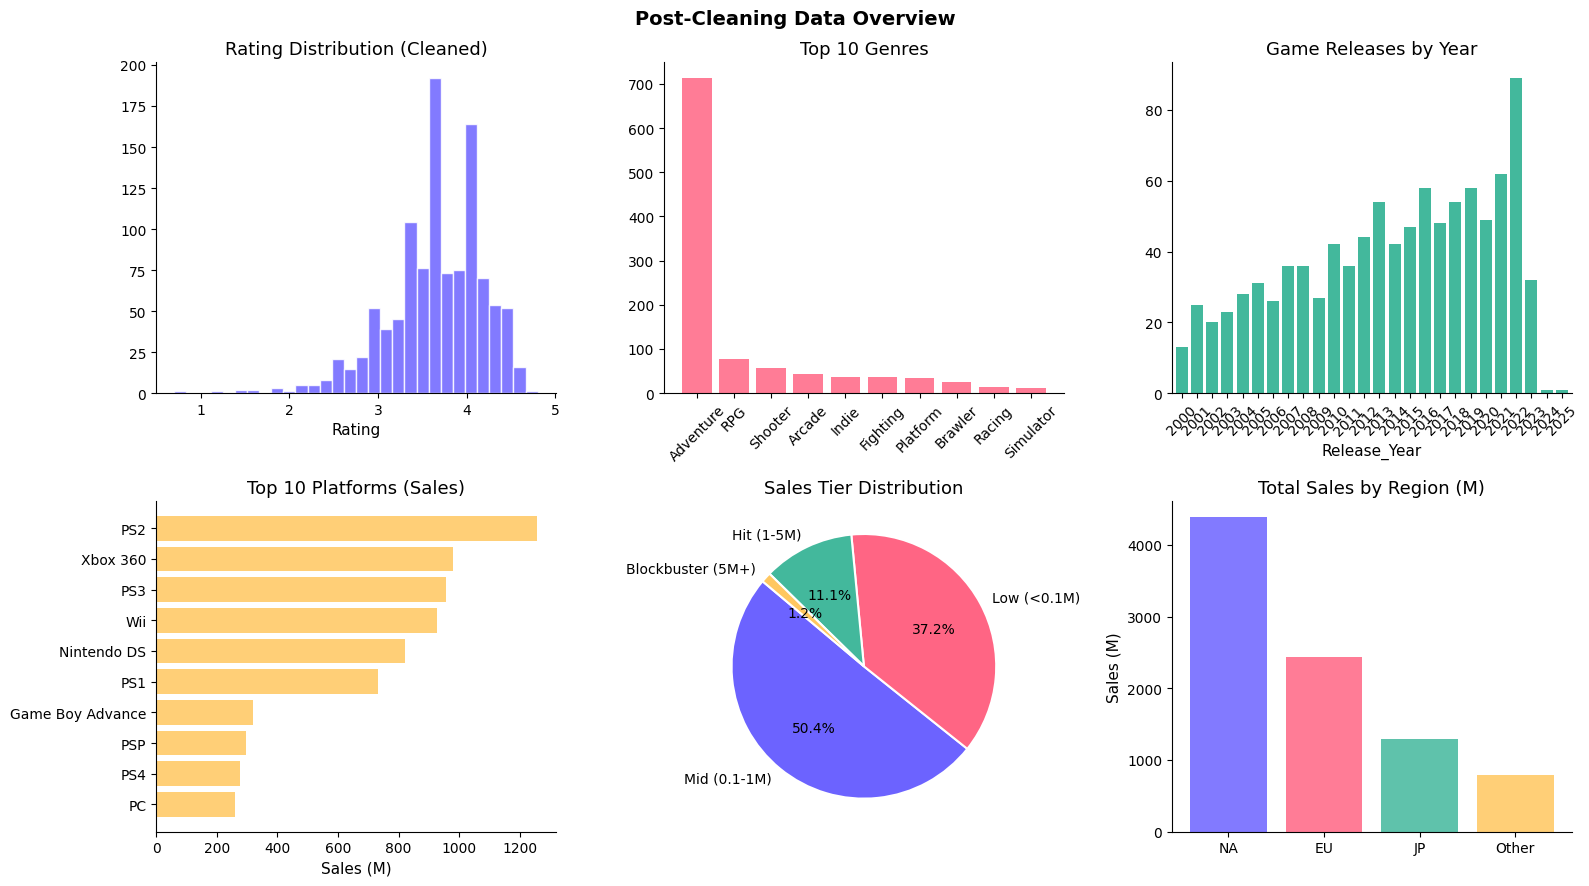

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Rating distribution after cleaning
axes[0,0].hist(games['Rating'].dropna(), bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0,0].set_title('Rating Distribution (Cleaned)')
axes[0,0].set_xlabel('Rating')

# 2. Top genres
g_genre = games['Primary_Genre'].value_counts().head(10)
axes[0,1].bar(g_genre.index, g_genre.values, color=PALETTE[1], alpha=0.85)
axes[0,1].set_title('Top 10 Genres')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Release year trend
year_c = games['Release_Year'].value_counts().sort_index()
year_c[year_c.index >= 2000].plot(kind='bar', ax=axes[0,2], color=PALETTE[2], width=0.8)
axes[0,2].set_title('Game Releases by Year')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. vgsales platform distribution
v_plat = vgsales.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
axes[1,0].barh(v_plat.index, v_plat.values, color=PALETTE[3], alpha=0.85)
axes[1,0].invert_yaxis()
axes[1,0].set_title('Top 10 Platforms (Sales)')
axes[1,0].set_xlabel('Sales (M)')

# 5. Sales tier distribution
tier_counts = vgsales['Sales_Tier'].value_counts()
axes[1,1].pie(tier_counts.values, labels=tier_counts.index,
    autopct='%1.1f%%', colors=PALETTE[:4],
    startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1,1].set_title('Sales Tier Distribution')

# 6. Regional sales comparison
regional = vgsales[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
axes[1,2].bar(['NA','EU','JP','Other'], regional.values, color=PALETTE[:4], alpha=0.85)
axes[1,2].set_title('Total Sales by Region (M)')
axes[1,2].set_ylabel('Sales (M)')

plt.suptitle('Post-Cleaning Data Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Null check after all cleaning
print('=== FINAL NULL CHECK ===')
print('\n── games.csv ──')
g_nulls = games.isnull().sum()
print(g_nulls[g_nulls > 0] if g_nulls.any() else 'No nulls remaining ✅')

print('\n── vgsales.csv ──')
v_nulls = vgsales.isnull().sum()
print(v_nulls[v_nulls > 0] if v_nulls.any() else 'No nulls remaining ✅')

print('\n── merged_data ──')
m_nulls = merged.isnull().sum()
print(m_nulls[m_nulls > 0].head(10) if m_nulls.any() else 'No nulls remaining ✅')

=== FINAL NULL CHECK ===

── games.csv ──
Release Date     3
Release_Year     3
Release_Month    3
Primary_Genre    3
dtype: int64

── vgsales.csv ──
No nulls remaining ✅

── merged_data ──
Release Date       3
Release_Year       3
Release_Month      3
Primary_Genre      3
Publisher        630
Genre_Sales      630
Platforms        630
dtype: int64


## Step 11 — Export Cleaned Data

In [29]:
os.makedirs('cleaned_data', exist_ok=True)

games.to_csv('cleaned_data/cleaned_games.csv',   index=False)
vgsales.to_csv('cleaned_data/cleaned_vgsales.csv', index=False)
merged.to_csv('cleaned_data/merged_data.csv',     index=False)

print('✅ Files exported to cleaned_data/')
print(f'   cleaned_games.csv   → {games.shape}')
print(f'   cleaned_vgsales.csv → {vgsales.shape}')
print(f'   merged_data.csv     → {merged.shape}')

✅ Files exported to cleaned_data/
   cleaned_games.csv   → (1099, 19)
   cleaned_vgsales.csv → (16593, 15)
   merged_data.csv     → (1099, 27)


## Step 12 — Cleaning Summary Report

In [30]:
summary = {
    'Dataset': ['games.csv', 'vgsales.csv', 'merged_data'],
    'Raw Rows': [games_raw.shape[0], vgsales_raw.shape[0], '-'],
    'Clean Rows': [games.shape[0], vgsales.shape[0], merged.shape[0]],
    'Rows Removed': [
        games_raw.shape[0] - games.shape[0],
        vgsales_raw.shape[0] - vgsales.shape[0],
        '-'
    ],
    'Columns': [games.shape[1], vgsales.shape[1], merged.shape[1]]
}

summary_df = pd.DataFrame(summary)
print('\n=========================================')
print('        DATA CLEANING SUMMARY')
print('=========================================')
display(summary_df)

print('\nActions Performed:')
actions = [
    ('Duplicates removed (games)  ', f"{games_raw.shape[0] - games.shape[0]} rows"),
    ('Duplicates removed (vgsales)', f"{vgsales_raw.shape[0] - vgsales.shape[0]} rows"),
    ('Ratings filled (median)     ', '13 values'),
    ('K/M notation parsed         ', 'Plays, Wishlist, Backlogs, Playing, etc.'),
    ('Release Date → Year/Month   ', 'Extracted Release_Year, Release_Month'),
    ('Genres/Team parsed          ', 'List strings → Primary_Genre, Primary_Developer'),
    ('Platform names normalized   ', '31 platforms standardized'),
    ('Genre casing fixed          ', 'title() applied'),
    ('Missing Publisher filled    ', 'Unknown'),
    ('New features added (games)  ', 'Engagement_Score, Demand_Index, Rating_Tier'),
    ('New features added (sales)  ', 'Sales_Tier, Decade, NA_Dominant'),
    ('Datasets merged             ', f'{(merged["Global_Sales"]>0).sum()} games matched'),
]
for action, detail in actions:
    print(f'  ✅  {action} : {detail}')


        DATA CLEANING SUMMARY


,Dataset,Raw Rows,Clean Rows,Rows Removed,Columns
0,games.csv,1512,1099,413,19
1,vgsales.csv,16598,16593,5,15
2,merged_data,-,1099,-,27



Actions Performed:
  ✅  Duplicates removed (games)   : 413 rows
  ✅  Duplicates removed (vgsales) : 5 rows
  ✅  Ratings filled (median)      : 13 values
  ✅  K/M notation parsed          : Plays, Wishlist, Backlogs, Playing, etc.
  ✅  Release Date → Year/Month    : Extracted Release_Year, Release_Month
  ✅  Genres/Team parsed           : List strings → Primary_Genre, Primary_Developer
  ✅  Platform names normalized    : 31 platforms standardized
  ✅  Genre casing fixed           : title() applied
  ✅  Missing Publisher filled     : Unknown
  ✅  New features added (games)   : Engagement_Score, Demand_Index, Rating_Tier
  ✅  New features added (sales)   : Sales_Tier, Decade, NA_Dominant
  ✅  Datasets merged              : 469 games matched
